# Working with Hydro-PE data
## NetCDF version using Python + Xarray
**Authors:** [Matt Dalle Piagge](https://mattjbr123.github.io/) and Kit Macleod. With help from: Matt Fry, Mike Brown, Anna Rose Klaptocz, Faiza Samreen, Matt Coole

---

**Launch this notebook:**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/notebooks/Hydro-PE/hydrope_netcdf_python.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/NERC-CEH/fdri-gridded-notebooks/HEAD?labpath=notebooks/Hydro-PE/hydrope_netcdf_python.ipynb)

(CTRL + Click to open in a new tab)

Full instructions available in the [accompanying README](https://github.com/NERC-CEH/fdri-gridded-notebooks/blob/main/README.md#python).


---

## What this notebook does

This notebook explores the **Hydro-PE** dataset. [Hydro-PE](https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca) is an observations-derived gridded Potential Evaporation dataset for the UK produced by [UKCEH](https://www.ceh.ac.uk/) using the [HadUK-Grid](https://dx.doi.org/10.5285/f02cc6ddd92f45b18b9ab6ab544df7d9) dataset. It contains two variables, Potential Evapotranspiration (PE or PET) and Potential Evapotranspiration with Interception correction (PETI). See the supporting documentation on the [catalogue page](https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca) for more information on how these are calculated.

Simple examples are shown for exploring and working with the dataset, which can be generalised to any gridded dataset stored in NetCDF format.

A key limitation of working with NetCDF is that data files have to be downloaded to your machine - or wherever you are running the notebook - before you can work with them. This is why we also provide a [version](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/notebooks/Hydro-PE/hydrope_zarr_python.ipynb) of this notebook that uses the Zarr format instead, which removes the limitation and allows you to work with multi-terabyte datasets without worrying about having to download it all.

We will:

- Show how to open a dataset stored in NetCDF format
- Show how to extract and plot a time series at a single location, and demonstrate the limitations of NetCDF for this
- Show how to plot a map at a single time step

Data store: The data is currently publicly available via the EIDC: https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca

---

## 0. Setup

### Google Colab

If running on Google Colab, a few extra packages need to be installed for the notebook to run properly:

In [ ]:
# Install if needed (safe to run even if already installed)
%pip install -q netcdf4 cartopy xoak s3fs

You may see a message like "ERROR: pip's dependency resolver does not currently take into account all the packages that are installed...", but that's fine, the packages we need still get installed.

**All platforms:** Import the packages we need:

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import xoak

print(f"xarray  version: {xr.__version__}")

xarray  version: 2025.12.0


---
## 1. Download the NetCDF file


To work with NetCDF data we have to download the files ourselves, to our local machines (desktops/laptops), or wherever this notebook is running. A dataset in NetCDF format is usually split up into several files, typically across the time dimension.

To see what files are available, go to the [catalogue web-page](https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca) for this dataset and click 'Download', then the Download button next to the 'Direct Access Files' option that appears from the left.

Looking at the filenames tells you that the dataset is split into monthly files across the time span it covers. Looking at the sizes in the 3rd column tells you that each file is around 40MB. You can also see that there are a lot of files. Each file contains a month's worth of daily PET or PETI values across the UK.

We will therefore download only a single file of the data, obtaining the URL by right clicking on the file of interest (in this case for Jan 2000's PET) and selecting 'Copy Link'. This link is used below to download the file:

In [3]:
nc_url = (
    "https://catalogue.ceh.ac.uk/datastore/eidchub/2aa2c8ab-9e32-4b3b-9636-503912305aca/hydro-pe_hadukgrid_pet_1km_day_20000101-20000131.nc"
)

!wget "{nc_url}"

--2026-07-14 11:43:51--  https://catalogue.ceh.ac.uk/datastore/eidchub/2aa2c8ab-9e32-4b3b-9636-503912305aca/hydro-pe_hadukgrid_pet_1km_day_20000101-20000131.nc
Resolving catalogue.ceh.ac.uk (catalogue.ceh.ac.uk)... 192.171.173.198
Connecting to catalogue.ceh.ac.uk (catalogue.ceh.ac.uk)|192.171.173.198|:443... connected.
HTTP request sent, awaiting response... 200 
Length: 40937090 (39M) [application/octet-stream]
Saving to: ‘hydro-pe_hadukgrid_pet_1km_day_20000101-20000131.nc’

hydro-pe_hadukgrid_ 100%[===================>]  39.04M  6.25MB/s    in 7.6s    

2026-07-14 11:44:00 (5.13 MB/s) - ‘hydro-pe_hadukgrid_pet_1km_day_20000101-20000131.nc’ saved [40937090/40937090]



If wget doesn't work, try curl:

In [ ]:
!curl "{nc_url}"

Now you can download one of the files from the datasets by right clicking on the file of interest (in this case for Jan 2000) and selecting 'Copy Link'. This link is used below to download the file.

In [4]:
nc_filename = nc_url.split("/")[-1]
ds = xr.open_dataset(nc_filename)

# Display the dataset summary — dimensions, variables, coordinates, attributes
ds

<xarray.Dataset> Size: 172MB
Dimensions:    (time: 31, bnds: 2, x: 900, y: 1450)
Coordinates:
  * time       (time) datetime64[ns] 248B 2000-01-01T12:00:00 ... 2000-01-31T...
  * x          (x) float32 4kB -1.995e+05 -1.985e+05 ... 6.985e+05 6.995e+05
  * y          (y) float32 6kB -1.995e+05 -1.985e+05 ... 1.248e+06 1.25e+06
    lat        (y, x) float32 5MB ...
    lon        (y, x) float32 5MB ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 496B ...
    x_bnds     (x, bnds) float32 7kB ...
    y_bnds     (y, bnds) float32 12kB ...
    crsOSGB    int32 4B ...
    pet        (time, y, x) float32 162MB ...
Attributes: (12/33)
    title:                         Potential evapotranspiration derived from ...
    summary:                       Gridded potential evapotranspiration calcu...
    source:                        This dataset was derived from the HadUK-Gr...
    cdm_data_type:                 grid
    standard_name_vocabulary:      CF Standard Name Table v77, http://cfconve...
    standard_name_url_vocabulary:  NERC Vocabulary Server, https://vocab.nerc...
    ...                            ...
    publisher_name:                NERC EDS Environmental Information Data Ce...
    publisher_url:                 https://www.eidc.ac.uk
    publisher_email:               info@eidc.ac.uk
    publisher_institution:         NERC EDS Environmental Information Data Ce...
    publisher_type:                institution
    Conventions:                   CF-1.8, ACDD-1.3

---
## 2. Time series at a single location

Xarray allows you to select out a location using the dataset coordinates, instead of having to worry about indexing.

You can use any of the coordinate variables in the dataset, not just those that the data is actually on. For the Hydro-PE dataset it is on the x/y coordinates of the OS National Grid, but you may prefer to select out points based on longitude and latitude, for which a further example is available at the end of this notebook. All FDRI datasets, and in fact all datasets that adhere to the CF-Conventions, will also have longitude and latitude coordinates pre-calculated if the data is not already on a lon/lat grid.  Look at the 'Coordinates' section in the view of the dataset metadata in Section 1 to see what coordinates are available.

**Key Point:** To plot different months we would have to download the relevant files of the dataset as we did in Section 1. If we wanted to plot multiple months we would have to download multiple large files, if not the whole dataset, which quickly gets unwieldy given the size of the dataset. For increased flexibility and ease-of-use, consider using the Zarr version of the dataset instead via [this notebook](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/notebooks/Hydro-PE/hydrope_zarr_python.ipynb).

#### Using x/y coordinates

We can see from the metadata view in Section 1 that the data variables are on an x/y grid. We can use these x/y coordinates to select out a data point to view.

In [5]:
ds['x']

<xarray.DataArray 'x' (x: 900)> Size: 4kB
array([-199500., -198500., -197500., ...,  697500.,  698500.,  699500.],
      dtype=float32)
Coordinates:
  * x        (x) float32 4kB -1.995e+05 -1.985e+05 ... 6.985e+05 6.995e+05
Attributes:
    units:          m
    axis:           X
    long_name:      easting of British National Grid (BNG) coordinate system
    standard_name:  projection_x_coordinate
    bounds:         x_bnds

In [6]:
ds['y']

<xarray.DataArray 'y' (y: 1450)> Size: 6kB
array([-199500., -198500., -197500., ..., 1247500., 1248500., 1249500.],
      dtype=float32)
Coordinates:
  * y        (y) float32 6kB -1.995e+05 -1.985e+05 ... 1.248e+06 1.25e+06
Attributes:
    units:          m
    axis:           Y
    long_name:      northing of British National Grid (BNG) coordinate system
    standard_name:  projection_y_coordinate
    bounds:         y_bnds

In [7]:
# Choose a location — e.g. Edinburgh, Scotland
# Adjust to any point within the dataset's extent
target_x = 500000
target_y = 200000

# The variable name — see the 'Data variables' of the view of the dataset metadata in Section 1
var_name = "pet"

# Select the nearest grid cell
# The coordinate names depend on the store — common names: longitude/latitude, lon/lat, x/y
ts = ds[var_name].sel(x=target_x, y=target_y, method='nearest')

In [8]:
ts

<xarray.DataArray 'pet' (time: 31)> Size: 124B
[31 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 248B 2000-01-01T12:00:00 ... 2000-01-31T12...
    lat      float32 4B ...
    lon      float32 4B ...
    x        float32 4B 5.005e+05
    y        float32 4B 2.005e+05
Attributes:
    standard_name:      water_potential_evaporation_flux
    standard_name_url:  http://vocab.nerc.ac.uk/standard_name/water_potential...
    long_name:          Potential evapotranspiration
    units:              kg m-2 d-1
    grid_mapping:       crsOSGB
    actual_range:       [0.        2.9185927]
    cell_methods:       time: mean

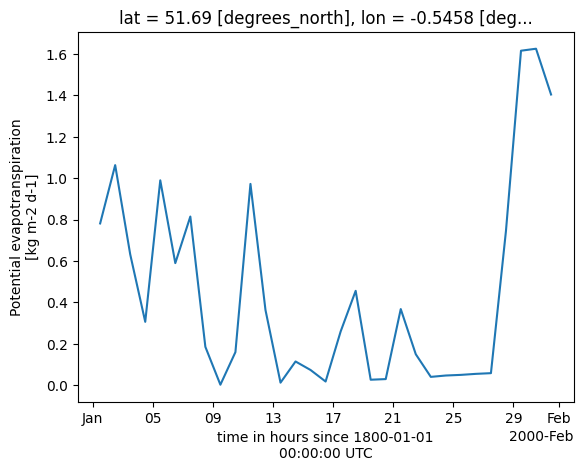

In [9]:
ts.plot()

Or you can customise the plot using matplotlib, the standard python plotting library, but this requires a few more lines of code to setup the plot and tweak the things you might want to:

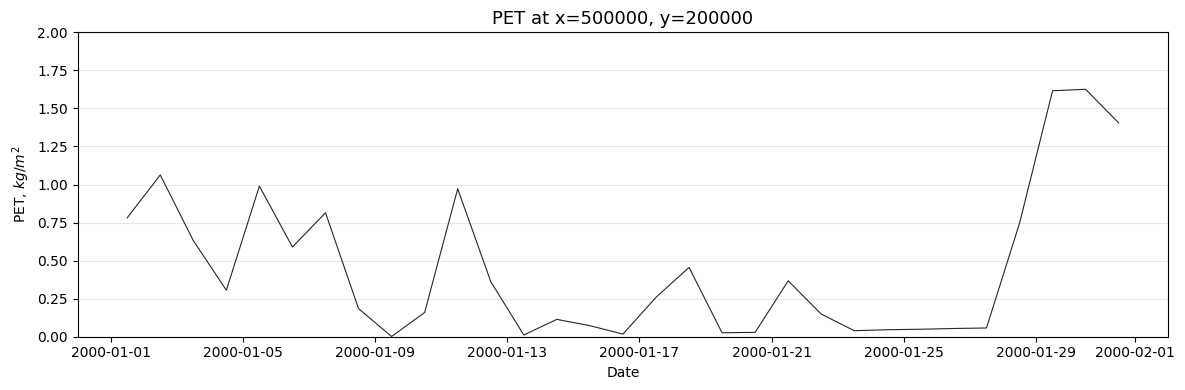

In [10]:
fig, ax = plt.subplots(figsize=(12, 4)) # customize the size of the plot

# plot the data on the axes (ax) we just created using ax.plot(x values, y values, customisations...)
# customize the line colour, width and transparency (alpha)
ax.plot(ts.time, ts.values, color="black", linewidth=0.8, alpha=0.85)

ax.set_title(f"PET at x={target_x}, y={target_y}", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("PET, " + r'$kg/m^2$')
ax.set_ylim([0, 2])
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

---
## 3. Map at a single time step

Select one time step and load the full spatial grid. xarray's `.plot()` creates a quick map from any 2-D DataArray. You can use the time coordinate values to select, instead of having to worry about indexing.

In [11]:
# Select a time step
# You can use sel(time="YYYY-MM-DD") for date-based selection
t = "2000-01-01"
var_name = 'pet'
daymap = ds[var_name].sel(time=t).squeeze() # the .squeeze() removes the singleton time dimension

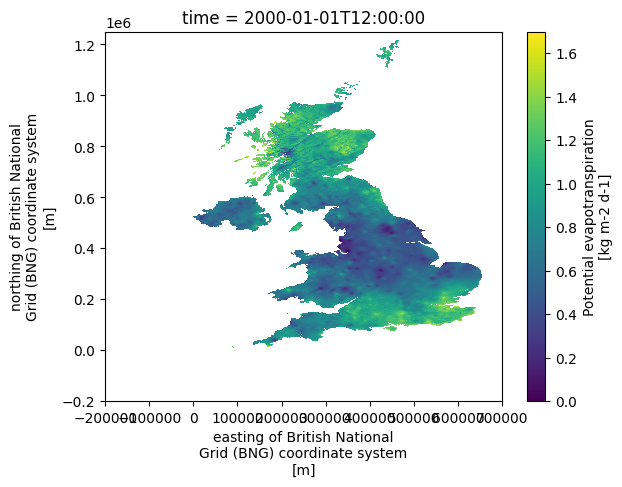

In [12]:
daymap.plot()

But as before we can also customise the plot. For maps, the [cartopy](https://cartopy.readthedocs.io/stable/) library is generally best.

In [13]:
import cartopy.crs as ccrs # the set of map projections cartopy supports
import cartopy as cp # the full cartopy package

Passing the projection 'key-word argument' to the plotting function tells the plotting library to invoke cartopy to draw the plot using a given map projection. Here we are using the 'OSGB' map projection (a cartesian grid, in other words a flat plane approximation that ignores the curvature of the earth) which a lot of UK hydrological data will be on. For any data that is on a 'lon/lat' grid instead of an 'x/y' grid, the ccrs.PlateCarree() projection is a better option.

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


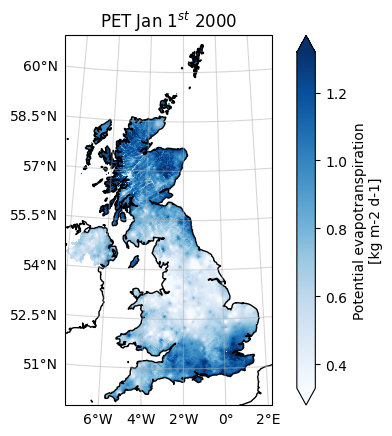

In [14]:
plot1 = daymap.plot.pcolormesh(cmap='Blues', robust=True, subplot_kws=dict(projection=ccrs.OSGB())) # create the initial plot
plt.title(r'PET Jan $1^{st}$ 2000')
plot1.axes.coastlines() # add coastlines
gl = plot1.axes.gridlines(draw_labels=['bottom' ,'left'], alpha=0.5) # add gridlines. The alpha parameter is the transparency between 0 and 1.

---
## 4. Catchment extraction

We can also extract out a particular river catchment to look at, instead of the whole UK.

To do this we need the [geopandas](https://geopandas.org/en/stable/getting_started/introduction.html) library, a shapefile to use for the subsetting, and some extra code utilities.

Fetch code utilities:

In [ ]:
!wget https://github.com/NERC-CEH/UKCEH_Summer_School/raw/refs/heads/main/Workshop_3/utils.py

from utils import *

If running on Windows, and some Linux environments you'll need to use curl instead of wget:

In [ ]:
!curl -L -o utils.py https://github.com/NERC-CEH/UKCEH_Summer_School/raw/refs/heads/main/Workshop_3/utils.py

from utils import *

Load geopandas

In [16]:
import geopandas as gpd

Read in the shapefile from the cloud (publically available for use):

In [17]:
sfname = 's3://example-data/gb_catchments.zip'
fs_shp = s3fs.S3FileSystem(anon=True, endpoint_url="https://fdri-o.s3-ext.jc.rl.ac.uk")
sfile = gpd.read_file(fs_shp.open(sfname))

sfile

,OBJECTID,ID_STRING,ID,SHAPE_AREA,SHAPE_LEN,geometry
0,227,18010,18010.0,0.0,0.0,"POLYGON ((271449.998 695224.998, 271400 695224..."
1,244,21014,21014.0,0.0,0.0,"POLYGON ((310900.002 628474.999, 311150.002 62..."
2,245,21015,21015.0,0.0,0.0,"POLYGON ((356475.002 638850.002, 356349.999 63..."
3,247,21017,21017.0,0.0,0.0,"POLYGON ((323424.998 613149.998, 323375 613100..."
4,269,22004,22004.0,0.0,0.0,"POLYGON ((421150.002 612925, 421225.001 612850..."
...,...,...,...,...,...,...
1888,174,21003,21003.0,0.0,0.0,"POLYGON ((325775.002 640050, 325775.002 640000..."
1889,187,19021,19021.0,0.0,0.0,"POLYGON ((333800.001 667825.002, 333900.002 66..."
1890,197,20806,20806.0,0.0,0.0,"POLYGON ((363849.998 677374.998, 364024.998 67..."
1891,204,17004,17004.0,0.0,0.0,"POLYGON ((333000 699774.998, 333100.001 699774..."


<details>
<summary>

**Instructions for using your own shapefile:** It is also straightforward to use your own shapefile with this code. Click for instructions.
</summary>

**Colab:** Click the folder icon on the left side-panel, then the upload icon (the leftmost icon above the folder list that appears in the extended side-panel). Select your shapefile (ends in .shp) and it's ancillary files (.sbn, .sbx, .shx, .sbn, .dbf, .cpg etc.). They can then be read in with ```sfile = gpd.open_file('shapefile_name.shp') ```. Note that the files will not be retained when the runtime ends, which is after a few minutes of inactivity ro when you navigate away from the webpage.

**Binder:** Click the folder icon on the left side-panel, then the upload icon (the button second right of the blue plus button). Select your shapefile (ends in .shp) and it's ancillary files (.sbn, .sbx, .shx, .sbn, .dbf, .cpg etc.). They can then be read in with ```sfile = gpd.open_file('shapefile_name.shp') ```. Note that the files will not be retained when your session ends.

**Local machine:** This as simple as running the code ```sfile = gpd.open_file('path/to/shapefile.shp') ```
</details>

With geopandas each shape in the shapefile is represented by a row in the table, and the metadata associated with each shape by the columns. The geometry column contains the vector information that describes the actual shape.

We can use the subsetting script to cut out a piece of our dataset according to one or more shapes in the shapefile.

This is the convenience function I've developed to ease the process. Put a question mark after a given function, to see more information about it:

In [ ]:
catchment_subset_shapefile?

We can use any of the columns to identify which shapes we'd like to use to subset our data. In this case, the only helpful one is the 'ID' column, which refers to the ID of a given catchment in the NRFA database. These can be [explored here](https://nrfa.ceh.ac.uk/data/search).

Catchment ID 39001 is the 'Thames to Kingston' catchment, which is the entire non-tidal Thames basin.

In [18]:
cat39001data = catchment_subset_shapefile(data=daymap, sfname=sfname,
                                          endpoint="https://fdri-o.s3-ext.jc.rl.ac.uk",
                                          IDname='ID_STRING', IDs=['39001'], drop=1)

Found: 39001
Adding mask to xarray


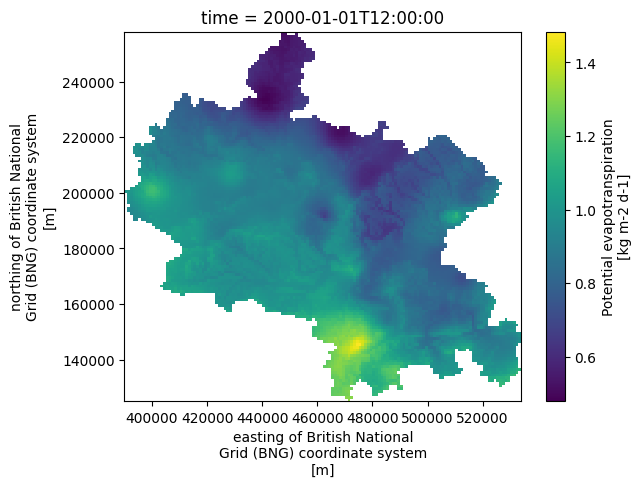

In [19]:
cat39001data.plot()

Or a better plot, where I've chose to highlight the Chess catchment too:

Text(0.5, 1.0, 'PET on 2000-01-01')

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


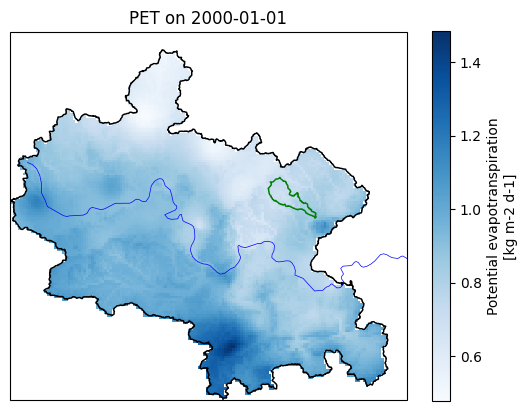

In [20]:
cat39001 = sfile.where(sfile['ID_STRING']=='39001').dropna() # Thames to Kingston
cat39088 = sfile.where(sfile['ID_STRING']=='39088').dropna() # Chess to Rickmansworth

gbax = plt.axes(projection=cp.crs.OSGB()) # create the (geo) axes for the plot
cat39001.plot(ax=gbax, facecolor='None', edgecolor='black', zorder=1) # plot the catchment shapefile, transparently (facecolor='None') and on top of the data (zorder=1)
cat39088.plot(ax=gbax, facecolor='None', edgecolor='green', zorder=1) # plot the catchment shapefile, transparently (facecolor='None') and on top of the data (zorder=1)
rivers = cp.feature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '10m', edgecolor='blue', facecolor='none', lw=0.5) # add in the river thames from a public data source (Natural Earth)
gbax.add_feature(rivers)
cat39001data.plot(ax=gbax, cmap='Blues', zorder=0) # add the data we extracted earlier to the plot
plt.title("PET on 2000-01-01")

---
## Appendix

### Some other commands to try

| Task | Code |
|------|------|
| Select a date range from the file | `ds[var].sel(time=slice("2000-01-01", "2000-01-10"))` |
| Temporal mean | `ds[var].mean(dim='time')` |
| Spatial mean over GB | `ds[var].mean(dim=["y", "x"])` |
| Save an edited NetCDF | `ds.to_netcdf("output.nc")` |

### Further resources

- [Zarr version of this notebook](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/notebooks/HadUK-Grid/hadukgrid_zarr_python.ipynb)
- [Information about the Zarr format](https://zarr.dev/)
- [Xarray documentation](https://docs.xarray.dev/en/stable/)
- [Xarray "common usage patterns" tutorial](https://tutorial.xarray.dev/intermediate/01-high-level-computation-patterns.html)
- [**2024** Summer School workshop notebook 1](https://github.com/hydro-jules/school/blob/main/HJ-SS_Workshop-4/HJ-SS_Workshop-4.ipynb), focusing on NetCDF
- [**2024** Summer School workshop notebook 2](https://github.com/hydro-jules/school/blob/main/HJ-SS_Workshop-5/HJ-SS_Workshop-5.ipynb), focusing on Zarr

#### Using lon/lat coordinates for selection instead of x/y

We can use lon/lat coordinates instead of x/y coordinates to select data too.

In [21]:
ds['lat']

<xarray.DataArray 'lat' (y: 1450, x: 900)> Size: 5MB
[1305000 values with dtype=float32]
Coordinates:
  * y        (y) float32 6kB -1.995e+05 -1.985e+05 ... 1.248e+06 1.25e+06
  * x        (x) float32 4kB -1.995e+05 -1.985e+05 ... 6.985e+05 6.995e+05
    lat      (y, x) float32 5MB ...
    lon      (y, x) float32 5MB ...
Attributes:
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north

In [22]:
ds['lon']

<xarray.DataArray 'lon' (y: 1450, x: 900)> Size: 5MB
[1305000 values with dtype=float32]
Coordinates:
  * y        (y) float32 6kB -1.995e+05 -1.985e+05 ... 1.248e+06 1.25e+06
  * x        (x) float32 4kB -1.995e+05 -1.985e+05 ... 6.985e+05 6.995e+05
    lat      (y, x) float32 5MB ...
    lon      (y, x) float32 5MB ...
Attributes:
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east

In [23]:
target_lon = -3.19
target_lat = 55.95
var_name = "pet"

points = xr.Dataset(
    {
        "lat": target_lat,
        "lon": target_lon,
    }
)
ds = ds.set_xindex(['lat', 'lon'], xr.indexes.NDPointIndex)
ts = ds[var_name].sel(lat=points.lat, lon=points.lon, method='nearest')

In [24]:
ts

<xarray.DataArray 'pet' (time: 31)> Size: 124B
[31 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 248B 2000-01-01T12:00:00 ... 2000-01-31T12...
    x        float32 4B 3.255e+05
    y        float32 4B 6.735e+05
    lat      float32 4B 55.95
    lon      float32 4B -3.193
Attributes:
    standard_name:      water_potential_evaporation_flux
    standard_name_url:  http://vocab.nerc.ac.uk/standard_name/water_potential...
    long_name:          Potential evapotranspiration
    units:              kg m-2 d-1
    grid_mapping:       crsOSGB
    actual_range:       [0.        2.9185927]
    cell_methods:       time: mean

---
**Data citation:** Hydro-PE, UKCEH, https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca